### Authors
Julie DORNAT (julie.dornat@universite-paris-saclay.fr)

Marina HORNERO MERINO (marina.hornero-merino@universite-paris-saclay.fr)


In [266]:
import scispacy
import spacy

In [267]:
# Utility function
def print_pos(doc):
    print("PoS tokens:", end=" ")
    for token in doc:
        print(token.pos_, end=" | ")
    print("\n")

def print_token(doc):
    print("Tokens:", end=" ")
    for token in doc:
        print(token, end=" | ")
    print("\n")


## Part 1: PoS tagging

General domain:
- The cat sat on the couch.
- Time flies like an arrow.
- The spy saw the cop with the telescope.
- The spy saw the cop with the revolver. 

Specific domain:
- Biology: Arabidopsis thaliana seedlings exhibit longer hypocotyls when they are grown under high ambient temperature, which is defined as thermomorphogenesis.
- Astronomy: A spectrogram of PSN J10354824+3900279 obtained on Dec. 19.33 UT suggests that this is a type-Ia at redshift z 0.044.

1. Manually annotate the sentences (you can consider General domain sentences only).
2. Compare to spacy PoS (both domain).
3. Compare to scispacy PoS (for speciality domain).

**Question 1**

Sentence 1
| The | Cat | sat | on | the | couch | . |
|:----- |:-----:|:-----:|:-----:|:-----:|:-----:|-----:|
| DET | NOUN | VERB | ADP | DET | NOUN | PUNCT |

Sentence 2: 
For the sentence below, there are several possibilities depending on the context. Here the context is "Time flies like an arrow; fruit flies like banana.":
| Time | flies | like | an | arrow | . |
|:----- |:-----:|:-----:|:-----:|:-----:|-----:|
| NOUN | VERB | ADP | DET | NOUN | PUNCT |

Sentence 3
| The | spy | saw | the | cop | with | the | telescope | . |
|:----- |:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|-----:|
| DET | NOUN | VERB | DET | NOUN | ADP | DET | NOUN | PUNCT |
 
Sentence 4
| The | spy | saw | the | cop | with | the | revolver | . |
|:----- |:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|-----:|
| DET | NOUN | VERB | DET | NOUN | ADP | DET | NOUN | PUNCT |

In [268]:
nlp = spacy.load("en_core_web_sm")

texts = [("The cat sat on the couch."), ("Time flies like an arrow."),
("The spy saw the cop with the telescope."),
("The spy saw the cop with the revolver.")]
# text = ("The cat sat on the couch")

# text1 = ()
for text in texts:
    print(text)
    doc = nlp(text)
    print_pos(doc)

The cat sat on the couch.
PoS tokens: DET | NOUN | VERB | ADP | DET | NOUN | PUNCT | 

Time flies like an arrow.
PoS tokens: NOUN | VERB | ADP | DET | NOUN | PUNCT | 

The spy saw the cop with the telescope.
PoS tokens: DET | NOUN | VERB | DET | NOUN | ADP | DET | NOUN | PUNCT | 

The spy saw the cop with the revolver.
PoS tokens: DET | NOUN | VERB | DET | NOUN | ADP | DET | NOUN | PUNCT | 



**Analysis**

Spacy find the exact same PoS token as those we manually established for each general domain sentences. Spacy is reliable with what we can expect intuitively.

In addition, we should remark that general domain sentences use standard vocabulary and syntactic structures. It works well with Spacy model which is directly trained on common English texts.

In [269]:
text_biology = ("Arabidopsis thaliana seedlings exhibit longer hypocotyls when they are grown under high ambient temperature, which is defined as thermomorphogenesis.")
text_astronomy = ("A spectrogram of PSN J10354824+3900279 obtained on Dec. 19.33 UT suggests that this is a type-Ia at redshift z 0.044.")

doc_biology = nlp(text_biology)
print(text_biology)
print_pos(doc_biology)

print(text_astronomy)
doc_astronomy = nlp(text_astronomy)
print_pos(doc_astronomy)

Arabidopsis thaliana seedlings exhibit longer hypocotyls when they are grown under high ambient temperature, which is defined as thermomorphogenesis.
PoS tokens: NOUN | NOUN | NOUN | VERB | ADV | NOUN | SCONJ | PRON | AUX | VERB | ADP | ADJ | ADJ | NOUN | PUNCT | PRON | AUX | VERB | ADP | NOUN | PUNCT | 

A spectrogram of PSN J10354824+3900279 obtained on Dec. 19.33 UT suggests that this is a type-Ia at redshift z 0.044.
PoS tokens: DET | NOUN | ADP | PROPN | PROPN | PROPN | NUM | VERB | ADP | PROPN | NUM | PROPN | VERB | SCONJ | PRON | AUX | DET | NOUN | PUNCT | NOUN | ADP | NOUN | PROPN | NUM | PUNCT | 



**Analysis**

Spacy remarkably identifies biological species such as “Arabidopsis thaliana seedlings” as a sequence of NOUNs. However, it has difficulty understanding that “PSN J10354824+3900279” is a serial number. It flags it as a proper noun. This may be due to a lack of diversity in the proposed grammar. Similarly, since it has no definitions for abbreviations in its grammar, “Dec.” is identified as a proper noun (PROPN).

In [270]:
# with scispacy

nlp2 = spacy.load("en_core_sci_sm")

print(text_biology)
doc_biology_sci = nlp2(text_biology)
print_pos(doc_biology_sci)

print(text_astronomy)
doc_astronomy_sci = nlp2(text_astronomy)
print_pos(doc_astronomy_sci)

Arabidopsis thaliana seedlings exhibit longer hypocotyls when they are grown under high ambient temperature, which is defined as thermomorphogenesis.
PoS tokens: NOUN | NOUN | NOUN | VERB | ADV | ADJ | SCONJ | PRON | AUX | VERB | ADP | ADJ | ADJ | NOUN | PUNCT | DET | AUX | VERB | ADP | NOUN | PUNCT | 

A spectrogram of PSN J10354824+3900279 obtained on Dec. 19.33 UT suggests that this is a type-Ia at redshift z 0.044.
PoS tokens: DET | NOUN | ADP | NOUN | NOUN | CCONJ | NUM | VERB | ADP | PROPN | NUM | PROPN | VERB | SCONJ | DET | AUX | DET | NOUN | ADP | NOUN | NOUN | NUM | PUNCT | 



In [271]:
# Compare with spacy and with scispacy
is_same = True
for token, token_sci in zip(doc_biology, doc_biology_sci):
    if token.pos_ != token_sci.pos_:
        print(f"Different tokens: ({token}, {token_sci})")
        print(f"Different pos: ({token.pos_}, {token_sci.pos_})")

is_same = False

is_same = True
for token, token_sci in zip(doc_astronomy, doc_astronomy_sci):
    if token.pos_ != token_sci.pos_:
        print(f"Different tokens: ({token}, {token_sci})")
        print(f"Different pos: ({token.pos_}, {token_sci.pos_})")
is_same = False 

if is_same:
    print("Exactly the same!")


print(text_biology)
print_pos(doc_biology)
print_pos(doc_biology_sci)

print(text_biology)
print_token(doc_biology)
print_token(doc_biology_sci)

print(text_astronomy)
print_pos(doc_astronomy)
print_pos(doc_astronomy_sci)

print(text_astronomy)
print_token(doc_astronomy)
print_token(doc_astronomy_sci)

Different tokens: (hypocotyls, hypocotyls)
Different pos: (NOUN, ADJ)
Different tokens: (which, which)
Different pos: (PRON, DET)
Different tokens: (PSN, PSN)
Different pos: (PROPN, NOUN)
Different tokens: (J10354824, J10354824)
Different pos: (PROPN, NOUN)
Different tokens: (+, +)
Different pos: (PROPN, CCONJ)
Different tokens: (this, this)
Different pos: (PRON, DET)
Different tokens: (-, at)
Different pos: (PUNCT, ADP)
Different tokens: (at, z)
Different pos: (ADP, NOUN)
Different tokens: (redshift, 0.044)
Different pos: (NOUN, NUM)
Different tokens: (z, .)
Different pos: (PROPN, PUNCT)
Arabidopsis thaliana seedlings exhibit longer hypocotyls when they are grown under high ambient temperature, which is defined as thermomorphogenesis.
PoS tokens: NOUN | NOUN | NOUN | VERB | ADV | NOUN | SCONJ | PRON | AUX | VERB | ADP | ADJ | ADJ | NOUN | PUNCT | PRON | AUX | VERB | ADP | NOUN | PUNCT | 

PoS tokens: NOUN | NOUN | NOUN | VERB | ADV | ADJ | SCONJ | PRON | AUX | VERB | ADP | ADJ | ADJ |

**Analysis**

We should note that spaCy is a general NLP library pretrained on daily-life texts, while sciSpaCy is specially built for biomedical texts.
- **Hyphenated compounds:** Spacy and Scispacy handle hyphenated compounds (such as type-Ia) differently. Spacy's default English tokenizer splits hyphens whereas sciSpacy's tokenizer preserve this type of structure. General domain models struggle with specialized formatting like hyphens.
- **Adjective & Adverb Misclassification:** In both Spacy and Scispacy, "longer" is misclassified as an adverb rather than an adjective. This creates a shift in the subsequent tags, leading Scispacy to tag "hypocotyls" as an adjective instead of a noun.
- **Pronoun & Determiner Confusion:** Words like "which" are sometimes incorrectly tagged as determiners instead of pronouns. This is the case of the Scispacy PoS solution.
- **Auxiliary vs Verb Confusion:** In the astronomy sentence "that this is" is respectively translated as "SCONJ | PRON | AUX" and "SCONJ | DET | AUX" by Spacy and Scispacy. Here "is" is not an auxiliary but a verb and "this" refers to the subject so that it is a PRON.
- **Domain Scope:** Astronomy is outside the domain scope of Scispacy, so we might expect fewer differences compared to the general spacy version. However, it is not the case here, as the models show significant disagreements on the astronomical text.
- **Serial number handling:** Scispacy handles the serial number differently (for instance, identifying the + as a CCONJ), which highlights how its processing pipeline reacts to specialized scientific formatting compared to a general-domain model.

## Part 2: Syntactic Parsing / Constituency Parsing

1. Define a grammar and use the CYK algo on the different sentences.
2. Compare to Berkeley constituency parsing.

**Question 1**

To parse sentences using the Cocke–Younger–Kasami (CYK) algorithm, we defined a custom context-free grammar tailored to English syntax. Indeed, domains' sentences are all in English and Spacy model is made for English syntax. It will be more convenient to compare our results by keeping this context.

**Axiom and Core Structure:**
- Sentences (S) are defined primarily as combinations of Noun Phrases (NP) and Verb Phrases (VP), or standalone verb phrases.
- A sentence ends by a punctation. Punctuation marks are attached dynamically to phrases rather than being treated as standalone top-level elements.

This lead us to define:
```text
("S", ("VP",)),
("S", ("NP", "VP")),
("S", ("VP", "NP")),
```

**Non-terminal rules:**

To design our non terminal rules, we should consider the tradeoff between enough linguistic accuracy and combinatorial explosion. The objective is to construct a grammar sufficiently representative and able to mitigates the sentences of both domains.

- Prepositional Phrases (PP) capture relationships via prepositions (ADP) followed by an NP.
- Prepositional phrases can attach to either verb phrases or noun phrases.
- A preposition is typically not followed by a verb or an adjective in English.
- Subordinating conjunctions (SCONJ) link clauses together. It is usefull for sentences containing relative or conditional clauses.
- A subordination phrase can be present into a verb phrase if it contains a verb, or a noun phrase if it contains no verb.
- A verb phrase (VP) is defined through combinations of verbs, objects, auxiliaries, adverbs, and prepositional phrases.
- A verb phrase, such as a noun phrase may contain several verb phrases (resp noun phrases).
- A noun phrase is designed to capture nouns or proper nouns accompanied or unaccompanied by determiners, adjectives, or numbers.
- A noun phrase can be present into a context with linked words, adjectives, preprositions and conjunctions.


**Implementation 1 (Accepting NP as Terminals):** Allowing high level abstraction.

If we don't care on terminal node and accept that NP can be a terminal node, we have the following non terminal rule:

```text
    # PP
    ("PP", ("ADP", "NP")),

    # Conjunction of Subordination 
    ("VP", ("SCONJ", "VP")),
    ("NP", ("SCONJ", "NP")),

    # VP
    ("VP", ("VERB",)),
    ("VP", ("VERB", "NP")),  # for imperative sentence like "Stop!"
    # ("VP", ("NP", "VERB")), # already defined in S
    ("VP", ("VP", "VP")), # combinatorial explosion of possibilities
    ("VP", ("VP", "PP")),
    ("VP", ("PP", "VP")),
    ("VP", ("AUX", "VERB")),
    ("VP", ("ADV", "VERB")),
    #("VP", ("VERB", "VP")), # Can create redundancy
    ("VP", ("CCONJ", "VP")),
    ("VP", ("VP", "CCONJ")),

    # NP
    ("NP", ("NOUN",)),
    ("NP", ("PRON",)),
    ("NP", ("NUM",)),
    ("NP", ("PROPN",)),
    ("NP", ("ADJ", "NOUN")),
    ("NP", ("DET", "NP")),
    ("NP", ("NUM", "NOUN")), # e.g "the 2 bottle"
    ("NP", ("NP", "NP")), # combinatorial explosion of possibilities
    ("NP", ("CCONJ", "NP")),
    ("NP", ("NP", "CCONJ")),

    # Punctuation
    ("VP", ("VP", "PUNCT")),
    ("NP", ("NP", "PUNCT")),

```

**Implementation 2 (Explicit Combinatorial Rules):** To preserve granular PoS, write explicit rules for each case...

Otherwise we have the following non terminal rules:
```text
    # PP
    ("PP", ("ADP", "NP")),

    # Conjunction of Subordination 
    ("VP", ("SCONJ", "VP")),
    ("NP", ("SCONJ", "NP")),

    # VP
    # ("VP", ("VERB",)),

    ("VP", ("VERB", "NP")),  # for imperative sentence like "Stop!"
    # ("VP", ("NP", "VERB")), # already defined in S
    ("VP", ("PRON", "VP")),
    ("VP", ("NOUN", "VP")),
    ("VP", ("PROPN", "VP")),
    ("VP", ("NOUN", "VERB")),
    ("VP", ("PROPN", "VERB")),
    ("VP", ("PRON", "VERB")),
    ("VP", ("VP", "VP")), # combinatorial explosion of possibilities
    ("VP", ("VP", "PP")),
    ("VP", ("VERB", "PP")), # e.g "go up"
    ("VP", ("PP", "VP")),
    ("VP", ("PP", "VERB")),
    ("VP", ("AUX", "VERB")),
    ("VP", ("ADV", "VERB")),
    #("VP", ("VERB", "VP")), # Can create redundancy
    ("VP", ("CCONJ", "VP")),
    ("VP", ("CCONJ", "VERB")),
    ("VP", ("VP", "CCONJ")),
    ("VP", ("VERB", "CCONJ")),

    # NP
    # The following commented rules can be correct but lead to confusion when the tree is constructed. Indeed, the terminal nodes will be marked as NP. We don't want that, so we have to define each combinaison. A clean way could be to defined unitary rules that able CYK to go down to a PoS tag instead of stopping at the NP tag.
    #("NP", ("NOUN",)),
    #("NP", ("PRON",)),
    #("NP", ("NUM",)),
    #("NP", ("PROPN",)),

    ("NP", ("ADJ", "NOUN")),
    ("NP", ("ADJ", "PROPN")),
    ("NP", ("DET", "NP")),
    ("NP", ("DET", "NOUN")),
    ("NP", ("DET", "PROPN")),
    ("NP", ("NUM", "NOUN")), # e.g "the 2 bottle"
    # e.g "Arabidopsis thaliana seedlings":
    ("NP", ("PROPN", "NP")), 
    ("NP", ("PROPN", "PROPN")), 
    ("NP", ("NOUN", "NOUN")), # e.g "Time flies"
    ("NP", ("NP", "NP")), # combinatorial explosion of possibilities
    ("NP", ("CCONJ", "NP")),
    ("NP", ("NP", "CCONJ")),

    # Punctuation
    ("VP", ("VP", "PUNCT")),
    ("NP", ("NP", "PUNCT")),

```

**Encountered issues:**
- Rules like ("VP", ("VP", "VP")) create multiple equivalent parse trees for the same sentence and increases the structural ambiguity.
- In your second implementation, direct unary mappings like ("NP", ("NOUN",)) were avoided to prevent terminal nodes from abruptly collapsing into high-level phrases such as NP or VP, forcing explicit combinations (e.g., ("NP", ("DET", "NOUN"))). When we test our first implementation, that incorporates unary rules, the word from the terminal node was marked as "NP" instead of their specific nature ("NOUN", "PRON", "NUM", "PROPN"). 
- The second implementation increases the cognitive cost of establishing a complete grammar and the possible mistakes that can occur during the construction process.
- The CYK algorithm strictly requires rewritting binary rules such as A -> BC for non terminal rules.
- Bypassing unit rules means sentences with bare nouns or pronouns fail to parse unless corresponding rules are explicitly written, forcing a trade-off between strict parse tree depth and parser flexibility.
- Scientific texts frequently use complex multi-word proper noun and common noun sequences (e.g., "Arabidopsis thaliana seedlings"). Rules like ("NP", ("PROPN", "NP")) and ("NP", ("PROPN", "PROPN")) were introduced to capture these dense noun modifiers without requiring explicit determiners in our second implementation. However, it complexify our grammar which is not the case with our first implementation that reduce this to a single ("NP", ("NP", "NP")), rule.

In the following work, we decide to use the first implementation of non terminal rules (Accepting NP as Terminals).


**Terminal rules**

And our terminal rules are the following ones:
```text
   ("DET", ("DET",)),
    ("VERB", ("VERB",)),
    ("NOUN", ("NOUN",)),
    ("ADP", ("ADP",)),
    ("ADJ", ("ADJ",)),
    ("PUNCT", ("PUNCT",)),
    ("SCONJ", ("SCONJ",)),
    ("PRON", ("PRON",)),
    ("AUX", ("AUX",)),
    ("ADV", ("ADV",)),
    ("NUM", ("NUM",)),
    ("CCONJ", ("CCONJ",)),
    ("PROPN", ("PROPN",))
```

In [272]:

class Node():
    def __init__(self, type, left, right = None, word=None):
        self.type = type
        self.left = left
        self.right = right
        self.word = word

    def _recursive_repr(self, tab=0):
        s =  f"{'----' * tab}{self.type}"
        if self.word is not None:
            s += f" - {self.word}"
        s+= "\n"
        if self.left is not None:
            s+=  f"{self.left._recursive_repr(tab+1)}"
        if self.right is not None:
            s+=  f"{self.right._recursive_repr(tab+1)}"
        return s

    def __str__(self):
        return self._recursive_repr() + "\n"

    def __repr__(self,):
        return self._recursive_repr() + "\n"

class CYK():
    
    def __init__(self, grammar):
        """ A simple implementation of CYK algorithm
            Parameter:
                grammar : list
                    a list of production rule in chumsky normal form
                    each rule is defined by a tuple (P, (L,R)) with P
                    a non-terminal and L and R respectivelly the right 
                    and left of the production.

            Usage example: 
                sentence = ["The", "cat", "sat",  "on", "the", "couch"]
                pos =      [["DET"], ["NOUN"], ["VERB"], ["PREP"], ["DET"], ["NOUN"]]

                # defining the grammar rules
                G = [
                    # S is axiom
                    ("S", ("NP", "VP")), 
                    
                        # non terminal rules
                    ("NP", ("DET", "NOUN")),
                    ("PP", ("PREP", "NP")),
                    ("VP", ("VERB", "PP")),
                    
                    # terminal (if using pos directly)
                    ("DET", ("DET",)),
                    ("VERB", ("VERB",)),
                    ("NOUN", ("NOUN",)),
                    ("PREP", ("PREP",))
                ]
                cyk = CYK(G)
                cyk(pos, sentence) 

                ## SHOULD RETURN
                [S
                ----NP
                --------DET - The
                --------NOUN - cat
                ----VP
                --------VERB - sat
                --------PP
                ------------PREP - on
                ------------NP
                ----------------DET - the
                ----------------NOUN - couch
                ]
        """
        self.grammar = grammar

    
    def __call__(self, input_list, str):
        """ Apply the CYK algorithm on an input.

            Parameter: 
                input_list: the list of terminal (in our case a list)

            Return:
                List of tree that are recognized by the language
        """
        size = len(input_list)
        cyk_tab = [ [[] for _ in range(i+1)] for i in range(len(input_list)) ][::-1]
        
        # process terminals
        for i, tags_list in enumerate(input_list):
            for tag in tags_list:
                # for all terminal rules
                for production, rule in self.grammar: 
                    if(len(rule) == 1) and (tag in rule):
                        cyk_tab[0][i].append(Node(production, None, word=str[i]))
        for cyk_depth in range(2, size+1):
            left_levels = list(range(1, cyk_depth))
            right_levels = list(range(1, cyk_depth)[::-1])
            for start in range(0, size - cyk_depth + 1):
                for left_level, right_level in zip(left_levels, right_levels):
                    left_start = start
                    right_start = start + left_level
                    Al, Bl = cyk_tab[left_level-1][left_start], cyk_tab[right_level-1][right_start]
                    for p, j in self.grammar:
                        if(len(j) == 2):
                            l, r = j
                            A = [a for a in Al if(a.type == l)]
                            B = [b for b in Bl if(b.type == r)]
                            cyk_tab[cyk_depth-1][start] += [Node(p, a, b ) for a in A  for b in B]

        return [i for i in cyk_tab[-1][0]]


Test with teacher example:

In [273]:
sentence = ["The", "cat", "sat",  "on", "the", "couch"]
pos =      [["DET"], ["NOUN"], ["VERB"], ["PREP"], ["DET"], ["NOUN"]]

G = [
    # S is axiom
    ("S", ("NP", "VP")), 

        # non terminal rules
    ("NP", ("DET", "NOUN")),
    ("PP", ("PREP", "NP")),
    ("VP", ("VERB", "PP")),

    # terminal (if using pos directly)
    ("DET", ("DET",)),
    ("VERB", ("VERB",)),
    ("NOUN", ("NOUN",)),
    ("PREP", ("PREP",))
    ]
cyk = CYK(G)
cyk(pos, sentence) 

[S
 ----NP
 --------DET - The
 --------NOUN - cat
 ----VP
 --------VERB - sat
 --------PP
 ------------PREP - on
 ------------NP
 ----------------DET - the
 ----------------NOUN - couch
 ]

Test the teacher's grammar with another sentence:

In [274]:
sentence = ["The", "spy", "saw",  "the", "cop", "with", "the", "telescope"]
pos =      [["DET"], ["NOUN"], ["VERB"], ["DET"], ["NOUN"], ["PREP"], ["DET"], ["NOUN"]]

G = [
    # S is axiom
    ("S", ("NP", "VP")), 

    # non terminal rules
    ("NP", ("DET", "NOUN")),
    ("PP", ("PREP", "NP")),
    ("VP", ("VERB", "PP")),

    # terminal (if using pos directly)
    ("DET", ("DET",)),
    ("VERB", ("VERB",)),
    ("NOUN", ("NOUN",)),
    ("PREP", ("PREP",))
    ]
cyk = CYK(G)
cyk(pos, sentence) 

[]

The tree failed to be established because the sentence doesn't respect the grammar rules. 
Indeed, the pattern ["VERB"], ["DET"], ["NOUN"] corresponds to none of the non terminal rules.
The teacher gammar should be completed to mitigate richer sentences like "The spy saw the cop with the telescope."

Expanding the grammar to include auxiliary verbs (AUX), adverbs (ADV), and conjunctions (CCONJ) allows the CYK algorithm to successfully parse ambiguous prepositional attachment and multi-word noun chunks.

So let's try with our own grammar G2:

In [275]:
G2 = [
    # S is axiom
    ("S", ("VP",)),
    ("S", ("NP", "VP")),
    ("S", ("VP", "NP")),
    
   

    # non terminal rules
   # PP
    ("PP", ("ADP", "NP")),

    # Conjunction of Subordination 
    ("VP", ("SCONJ", "VP")),
    ("NP", ("SCONJ", "NP")),

    # VP
    ("VP", ("VERB",)),
    ("VP", ("VERB", "NP")),  # for imperative sentence like "Stop!"
    # ("VP", ("NP", "VERB")), # already defined in S
    ("VP", ("VP", "VP")), # combinatorial explosion of possibilities
    ("VP", ("VP", "PP")),
    ("VP", ("PP", "VP")),
    ("VP", ("AUX", "VERB")),
    ("VP", ("ADV", "VERB")),
    #("VP", ("VERB", "VP")), # Can create redundancy
    ("VP", ("CCONJ", "VP")),
    ("VP", ("VP", "CCONJ")),

    # NP
    ("NP", ("NOUN",)),
    ("NP", ("PRON",)),
    ("NP", ("NUM",)),
    ("NP", ("PROPN",)),
    ("NP", ("ADJ", "NOUN")),
    ("NP", ("ADJ", "ADJ")),
    ("NP", ("NOUN", "NOUN")),
    ("NP", ("NUM", "NOUN")), # e.g "the 2 bottle"
    ("NP", ("DET", "NP")),
    ("NP", ("NP", "NP")), # combinatorial explosion of possibilities
    ("NP", ("CCONJ", "NP")),
    ("NP", ("NP", "CCONJ")),

    # Punctuation
    ("VP", ("VP", "PUNCT")),
    ("NP", ("NP", "PUNCT")),

    
    # terminal (if using pos directly)
    ("DET", ("DET",)),
    ("VERB", ("VERB",)),
    ("NOUN", ("NOUN",)),
    ("ADP", ("ADP",)),
    ("ADJ", ("ADJ",)),
    ("PUNCT", ("PUNCT",)),
    ("SCONJ", ("SCONJ",)),
    ("PRON", ("PRON",)),
    ("AUX", ("AUX",)),
    ("ADV", ("ADV",)),
    ("NUM", ("NUM",)),
    ("CCONJ", ("CCONJ",)),
    ("PROPN", ("PROPN",))
    ]
cyk2 = CYK(G2)

In [276]:
sentence = ["The", "cat", "sat",  "on", "the", "couch", "."]
pos =      [["DET"], ["NOUN"], ["VERB"], ["ADP"], ["DET"], ["NOUN"], ["PUNCT"]]
cyk2(pos, sentence)

[S
 ----NP
 --------DET - The
 --------NP - cat
 ----VP
 --------VP - sat
 --------PP
 ------------ADP - on
 ------------NP
 ----------------DET - the
 ----------------NP
 --------------------NP - couch
 --------------------PUNCT - .
 ,
 S
 ----NP
 --------DET - The
 --------NP - cat
 ----VP
 --------VP - sat
 --------PP
 ------------ADP - on
 ------------NP
 ----------------NP
 --------------------DET - the
 --------------------NP - couch
 ----------------PUNCT - .
 ,
 S
 ----NP
 --------DET - The
 --------NP - cat
 ----VP
 --------VP
 ------------VP - sat
 ------------PP
 ----------------ADP - on
 ----------------NP
 --------------------DET - the
 --------------------NP - couch
 --------PUNCT - .
 ]

In [277]:
sentence = ["Time", "flies", "like",  "an", "arrow", "."]
pos =      [["NOUN"], ["VERB"], ["ADP"], ["DET"], ["NOUN"], ["PUNCT"]]

cyk2(pos, sentence) 

[S
 ----NP - Time
 ----VP
 --------VP - flies
 --------PP
 ------------ADP - like
 ------------NP
 ----------------DET - an
 ----------------NP
 --------------------NP - arrow
 --------------------PUNCT - .
 ,
 S
 ----NP - Time
 ----VP
 --------VP - flies
 --------PP
 ------------ADP - like
 ------------NP
 ----------------NP
 --------------------DET - an
 --------------------NP - arrow
 ----------------PUNCT - .
 ,
 S
 ----NP - Time
 ----VP
 --------VP
 ------------VP - flies
 ------------PP
 ----------------ADP - like
 ----------------NP
 --------------------DET - an
 --------------------NP - arrow
 --------PUNCT - .
 ]

Experiment with different POS tagging

In [278]:
sentence = ["Time", "flies", "like",  "an", "arrow", "."]
pos =      [["NOUN"], ["NOUN"], ["VERB"], ["DET"], ["NOUN"], ["PUNCT"]]

cyk2(pos, sentence) 

[S
 ----NP
 --------NOUN - Time
 --------NOUN - flies
 ----VP
 --------VERB - like
 --------NP
 ------------DET - an
 ------------NP
 ----------------NP - arrow
 ----------------PUNCT - .
 ,
 S
 ----NP
 --------NOUN - Time
 --------NOUN - flies
 ----VP
 --------VERB - like
 --------NP
 ------------NP
 ----------------DET - an
 ----------------NP - arrow
 ------------PUNCT - .
 ,
 S
 ----NP
 --------NOUN - Time
 --------NOUN - flies
 ----VP
 --------VP
 ------------VERB - like
 ------------NP
 ----------------DET - an
 ----------------NP - arrow
 --------PUNCT - .
 ,
 S
 ----NP
 --------NP - Time
 --------NP - flies
 ----VP
 --------VERB - like
 --------NP
 ------------DET - an
 ------------NP
 ----------------NP - arrow
 ----------------PUNCT - .
 ,
 S
 ----NP
 --------NP - Time
 --------NP - flies
 ----VP
 --------VERB - like
 --------NP
 ------------NP
 ----------------DET - an
 ----------------NP - arrow
 ------------PUNCT - .
 ,
 S
 ----NP
 --------NP - Time
 --------NP - flies
 --

In [279]:
sentence = ["The", "spy", "saw",  "the", "cop", "with", "the", "revolver", "."]
pos =      [["DET"], ["NOUN"], ["VERB"], ["DET"], ["NOUN"], ["ADP"], ["DET"], ["NOUN"], ["PUNCT"]]

cyk2(pos, sentence) 

[S
 ----NP
 --------DET - The
 --------NP - spy
 ----VP
 --------VP
 ------------VERB - saw
 ------------NP
 ----------------DET - the
 ----------------NP - cop
 --------PP
 ------------ADP - with
 ------------NP
 ----------------DET - the
 ----------------NP
 --------------------NP - revolver
 --------------------PUNCT - .
 ,
 S
 ----NP
 --------DET - The
 --------NP - spy
 ----VP
 --------VP
 ------------VERB - saw
 ------------NP
 ----------------DET - the
 ----------------NP - cop
 --------PP
 ------------ADP - with
 ------------NP
 ----------------NP
 --------------------DET - the
 --------------------NP - revolver
 ----------------PUNCT - .
 ,
 S
 ----NP
 --------DET - The
 --------NP - spy
 ----VP
 --------VP
 ------------VP
 ----------------VERB - saw
 ----------------NP
 --------------------DET - the
 --------------------NP - cop
 ------------PP
 ----------------ADP - with
 ----------------NP
 --------------------DET - the
 --------------------NP - revolver
 --------PUNCT - .


In [280]:
sentence = ["The", "spy", "saw",  "the", "cop", "with", "the", "telescope", "."]
pos = [["DET"], ["NOUN"], ["VERB"], ["DET"], ["NOUN"], ["ADP"], ["DET"], ["NOUN"], ["PUNCT"]]

cyk2(pos, sentence) 

[S
 ----NP
 --------DET - The
 --------NP - spy
 ----VP
 --------VP
 ------------VERB - saw
 ------------NP
 ----------------DET - the
 ----------------NP - cop
 --------PP
 ------------ADP - with
 ------------NP
 ----------------DET - the
 ----------------NP
 --------------------NP - telescope
 --------------------PUNCT - .
 ,
 S
 ----NP
 --------DET - The
 --------NP - spy
 ----VP
 --------VP
 ------------VERB - saw
 ------------NP
 ----------------DET - the
 ----------------NP - cop
 --------PP
 ------------ADP - with
 ------------NP
 ----------------NP
 --------------------DET - the
 --------------------NP - telescope
 ----------------PUNCT - .
 ,
 S
 ----NP
 --------DET - The
 --------NP - spy
 ----VP
 --------VP
 ------------VP
 ----------------VERB - saw
 ----------------NP
 --------------------DET - the
 --------------------NP - cop
 ------------PP
 ----------------ADP - with
 ----------------NP
 --------------------DET - the
 --------------------NP - telescope
 --------PUNCT -

Using a manual correction of what Spacy and Scispacy generate for specific domain, we run the CYK algorithm on our grammar.

In [281]:

sentence = [
    "Arabidopsis",
    "thaliana",
    "seedlings",
    "exhibit",
    "longer",
    "hypocotyls",
    "when",
    "they",
    "are",
    "grown",
    "under",
    "high",
    "ambient",
    "temperature",
    ",",
    "which",
    "is",
    "defined",
    "as",
    "thermomorphogenesis",
    ".",
]

pos = [
    ["NOUN"],
    ["NOUN"],
    ["NOUN"],
    ["VERB"],
    ["ADJ"],
    ["NOUN"],
    ["SCONJ"],
    ["PRON"],
    ["AUX"],
    ["VERB"],
    ["ADP"],
    ["ADJ"],
    ["ADJ"],
    ["NOUN"],
    ["PUNCT"],
    ["PRON"],
    ["AUX"],
    ["VERB"],
    ["ADP"],
    ["NOUN"],
    ["PUNCT"],
]


cyk2(pos, sentence) 

[S
 ----NP
 --------NP - Arabidopsis
 --------NP
 ------------NOUN - thaliana
 ------------NOUN - seedlings
 ----VP
 --------VP
 ------------VERB - exhibit
 ------------NP
 ----------------NP
 --------------------ADJ - longer
 --------------------NOUN - hypocotyls
 ----------------NP
 --------------------SCONJ - when
 --------------------NP - they
 --------VP
 ------------VP
 ----------------AUX - are
 ----------------VERB - grown
 ------------VP
 ----------------PP
 --------------------ADP - under
 --------------------NP
 ------------------------NP
 ----------------------------ADJ - high
 ----------------------------ADJ - ambient
 ------------------------NP
 ----------------------------NP
 --------------------------------NP - temperature
 --------------------------------PUNCT - ,
 ----------------------------NP - which
 ----------------VP
 --------------------VP
 ------------------------AUX - is
 ------------------------VERB - defined
 --------------------PP
 ------------------------A

In [282]:
sentence = [
    "A",
    "spectrogram",
    "of",
    "PSN",
    "J10354824",
    "+",
    "3900279",
    "obtained",
    "on",
    "Dec.",
    "19.33",
    "UT",
    "suggests",
    "that",
    "this",
    "is",
    "a",
    "type-Ia",
    "at",
    "redshift",
    "z",
    "0.044",
    ".",
]

pos = [
    ["DET"],
    ["NOUN"],
    ["ADP"],
    ["PROPN"],
    ["PROPN"],
    ["CCONJ"],
    ["NUM"],
    ["VERB"],
    ["ADP"],
    ["PROPN"],
    ["NUM"],
    ["PROPN"],
    ["VERB"],
    ["SCONJ"],
    ["PRON"],
    ["VERB"],
    ["DET"],
    ["NOUN"],
    ["ADP"],
    ["NOUN"],
    ["NOUN"],
    ["NUM"],
    ["PUNCT"],
]

cyk2(pos, sentence) 

[S
 ----NP
 --------DET - A
 --------NP - spectrogram
 ----VP
 --------PP
 ------------ADP - of
 ------------NP
 ----------------NP - PSN
 ----------------NP
 --------------------NP - J10354824
 --------------------NP
 ------------------------CCONJ - +
 ------------------------NP - 3900279
 --------VP
 ------------VP - obtained
 ------------VP
 ----------------PP
 --------------------ADP - on
 --------------------NP
 ------------------------NP - Dec.
 ------------------------NP
 ----------------------------NP - 19.33
 ----------------------------NP - UT
 ----------------VP
 --------------------VP
 ------------------------VERB - suggests
 ------------------------NP
 ----------------------------SCONJ - that
 ----------------------------NP - this
 --------------------VP
 ------------------------VP
 ----------------------------VERB - is
 ----------------------------NP
 --------------------------------DET - a
 --------------------------------NP - type-Ia
 ------------------------PP
 -------

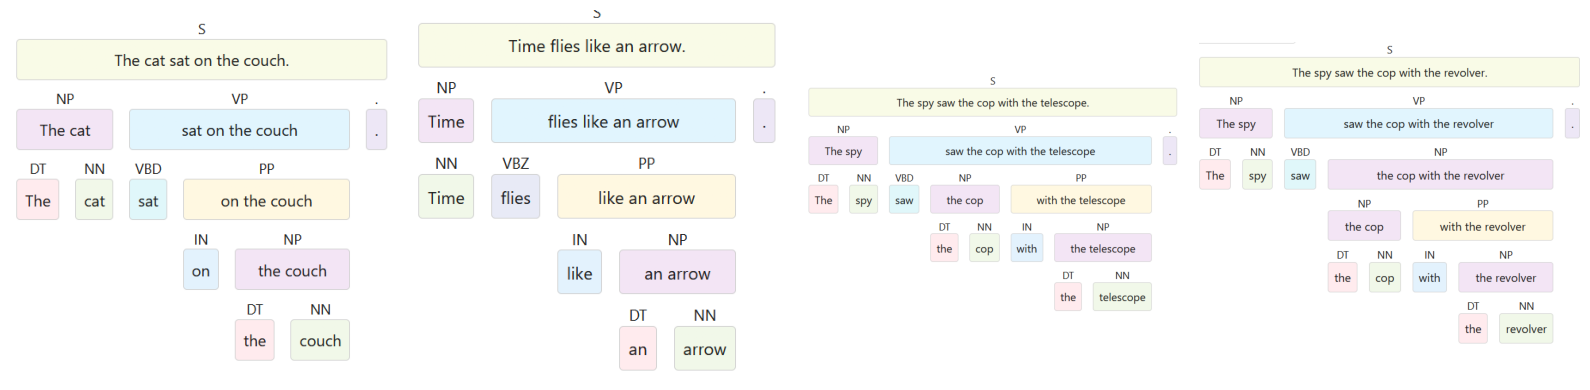

In [283]:
import matplotlib.pyplot as plt

# Replace these with the paths to your four image files
image_paths = ["sentence1Berkeley.png", "sentence2Berkeley.png", "sentence3Berkeley.png", "sentence4Berkeley.png"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, image_path in zip(axes, image_paths):
    image = plt.imread(image_path)
    ax.imshow(image)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Part 3: Observations

1. Difference between our parser and Berkeley's parser: There is a significant difference between our trees and those from Berkeley's parser. This is due to the same reason as before: it is not based on strict syntactic rules. Our rules, as defined in G2, for example, create a VP from a NP and a VERB. This would not allow the whole predicate to form before reaching the sentence level, and would instead form a VP from the subject + VERB. In practice, syntactical rules should be revised before allowing to create NLP models.
2. Many trees are created for some sentences: We can see that many trees are created for more complex sentences because our grammar rules are probably not the most efficient and potentially ambiguous. For example, we have ("NP", ("NP", "NP")). This derives an NP out of two NPs, but when we have three nouns, which create three corresponding NPs, our algorithm cyk2 would create different trees for each combination of pairs of nouns. This could be avoided by replacing this rule by language-specific rules.
3. Difference depending on the POS tagging:
```text
NP
----NP - Time
----NP
--------NP - flies
--------NP
------------ADP - like
------------NP
----------------NP
--------------------DET - an
--------------------NOUN - arrow
----------------PUNCT - .
```

When Time flies are both nouns, the phrase fails to become a sentence, because the rules we established do not allow to do so without a VP.
However, the same sentence with flies as a VERB reaches the sentence level, as seen below:
```text
S
----NP - Time
----VP
--------VERB - flies
--------NP
------------ADP - like
------------NP
----------------NP
--------------------DET - an
--------------------NOUN - arrow
----------------PUNCT - .
```